# Backpropagation

En una Red Neuronal con $N$ capas queremos optimizar aplicando algún método del **Gradiente Decendente**:

$$
W^{(l)} := W^{(l)} - \lambda \frac{\partial \mathcal{L}}{\partial W^{(l)}}
$$

donde cada capa tiene:

$$
z^{(l)} = h^{(l-1)} W^{(l)} + b^{(l)}, \quad h^{(l)} = \phi(z^{(l)})
$$

y nuestra función de perdida:

$$
\mathcal{L} = \mathcal{L}(h^{[N]}, y)
$$

# La pérdida solo se conoce al final

Para actualizar una capa, necesitas su contribución al error

Por ejemplo, para actualizar $W^{[1]}$ necesitas:

$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}}
$$

Usando la regla de la cadena:


$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}} 
=
\frac{\partial \mathcal{L}}{\partial h^{[3]}}
\frac{\partial h^{[3]}}{\partial z^{[3]}}
\frac{\partial z^{[3]}}{\partial h^{[2]}}
\frac{\partial h^{[2]}}{\partial z^{[2]}}
\frac{\partial z^{[2]}}{\partial h^{[1]}}
\frac{\partial h^{[1]}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial W^{[1]}}
$$

Para actualizar la capa 1 necesitas todas las capas posteriores. ¿Que pasaría si empiezo desde la capa 1?

### Capa 1
$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
h^{[1]} = \phi(z^{[1]})
$$

**Gradientes:**


$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial W^{[1]}}
$$


$$
\frac{\partial \mathcal{L}}{\partial b^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial b^{[1]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
= 
\frac{\partial \mathcal{L}}{\partial h^{[1]}}
\frac{\partial h^{[1]}}{\partial z^{[1]}}
$$

Si empiezas desde la capa 1:

- no tienes $\frac{\partial \mathcal{L}}{\partial h^{[1]}}$
- no tienes $\frac{\partial \mathcal{L}}{\partial z^{[1]}}$
- no sabes cuánto error proviene de cada neurona siguiente



## El error se distribuye hacia atrás

La red calcula:

$$
x \rightarrow h^{[1]} \rightarrow h^{[2]} \rightarrow h^{[3]} = \hat{y}
$$

y finalmente computa la pérdida:

$$
\mathcal{L}(\hat{y}, y)
$$

La pérdida $\mathcal{L}$ depende solo de la **salida final** $\hat{y}$.

Entonces:

- En la capa 1 no sabes el error
- En la capa 2 tampoco
- Solo en la capa de salida puedes calcular el error directamente.

Por lo tanto, el gradiente DEBE empezar en la capa de salida.


## Forward + Backpropagation (Ejemplo de Red Neuronal de 3 capas)

### Capa 3 (Salida)
$$
z^{[3]} = W^{[3]} h^{[2]} + b^{[3]}
$$

$$
\hat{y} = h^{[3]} = \phi(z^{[3]})
$$

**Pérdida:**
$$
\mathcal{L} = \mathcal{L}(\hat{y}, y)
$$

**Gradientes:**

$$
\frac{\partial \mathcal{L}}{\partial W^{[3]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[3]}}
\frac{\partial z^{[3]}}{\partial W^{[3]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial b^{[3]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[3]}}
\frac{\partial z^{[3]}}{\partial b^{[3]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial z^{[3]}}
= 
\frac{\partial \mathcal{L}}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z^{[3]}}
$$

---

### Capa 2
$$
z^{[2]} = W^{[2]} h^{[1]} + b^{[2]}
$$

$$
h^{[2]} = \phi(z^{[2]})
$$

**Gradientes:**


$$
\frac{\partial \mathcal{L}}{\partial W^{[2]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[2]}}
\frac{\partial z^{[2]}}{\partial W^{[2]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial b^{[2]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[2]}}
\frac{\partial z^{[2]}}{\partial b^{[2]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial z^{[2]}}
= 
\frac{\partial \mathcal{L}}{\partial h^{[2]}}
\frac{\partial h^{[2]}}{\partial z^{[2]}}
$$

$$
\frac{\partial \mathcal{L}}{\partial h^{[2]}}
= 
\frac{\partial \mathcal{L}}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial h^{[2]}}
$$

---

### Capa 1
$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
h^{[1]} = \phi(z^{[1]})
$$

**Gradientes:**

$$
\frac{\partial \mathcal{L}}{\partial W^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial W^{[1]}}
$$


$$
\frac{\partial \mathcal{L}}{\partial b^{[1]}}
=
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
\frac{\partial z^{[1]}}{\partial b^{[1]}}
$$


$$
\frac{\partial \mathcal{L}}{\partial z^{[1]}}
= 
\frac{\partial \mathcal{L}}{\partial h^{[1]}}
\frac{\partial h^{[1]}}{\partial z^{[1]}}
$$


In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [20]:
np.random.seed(42)
x = np.random.uniform(-1, 1, (100, 3)).astype(np.float32)
y = np.sum(x**2, axis=1, keepdims=True).astype(np.float32)  # y = x1^2 + x2^2 + x3^2

In [21]:
x.shape

(100, 3)

In [22]:
y.shape

(100, 1)

In [23]:
100 * 10

1000

In [24]:
# ---- Inicialización de pesos ----
W1 = tf.Variable(tf.random.normal([3, 10], stddev=0.1)) # num_features * num_neuronas_capa1
b1 = tf.Variable(tf.zeros([10]))

W2 = tf.Variable(tf.random.normal([10, 8], stddev=0.1)) # esta capa tiene 8 neuronas
b2 = tf.Variable(tf.zeros([8]))

W3 = tf.Variable(tf.random.normal([8, 1], stddev=0.1)) # 1 neuronas
b3 = tf.Variable(tf.zeros([1]))


In [25]:
W1

<tf.Variable 'Variable:0' shape=(3, 10) dtype=float32, numpy=
array([[ 0.00438724, -0.03933004,  0.0240052 ,  0.03832584, -0.02390553,
        -0.19546676, -0.10429579, -0.10767885, -0.02242155,  0.07485046],
       [-0.14292054, -0.02613982, -0.06466063,  0.05546861,  0.07286059,
         0.06190323, -0.01430524, -0.05685223, -0.13953538,  0.05822901],
       [ 0.14597677,  0.04331215, -0.17452967,  0.06587352,  0.12459417,
         0.09273034, -0.072921  , -0.16216326, -0.02217951, -0.02465451]],
      dtype=float32)>

In [26]:
b1

<tf.Variable 'Variable:0' shape=(10,) dtype=float32, numpy=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)>

In [27]:
tf.matmul(x, W1).shape

TensorShape([100, 10])

# ---- Forward pass ----

In [28]:
# layers.Dense(10)
# layers.Dense(8)
# layers.Dense(1)

def forward(x):
    # Capa 1
    z1 = tf.matmul(x, W1) + b1      # (100,3)*(3,10)=(100,10)
    h1 = z1             # (100,10)
    # Capa 2
    z2 = tf.matmul(h1, W2) + b2     # (100,10)*(10,8)=(100,8)
    h2 = z2             # (100,8)
    # Capa de salida
    z3 = tf.matmul(h2, W3) + b3     # (100,8)*(8,1)=(100,1)
    return z1, h1, z2, h2, z3

In [29]:
z1, h1, z2, h2, z3 = forward(x)

In [30]:
print(z1.shape, h1.shape)

(100, 10) (100, 10)


In [31]:
print(z2.shape, h2.shape)

(100, 8) (100, 8)


In [32]:
print(z3.shape)

(100, 1)


In [33]:
# ---- Entrenamiento ----
lr = 0.1
epochs = 400

for epoch in range(epochs):
    # Forward
    z1, h1, z2, h2, y_pred = forward(x)
    L = loss = tf.reduce_mean((y - y_pred)**2)
   
    # ---- Backpropagation ----
    # dL/dy_pred
    dL_dy = 2 * (y_pred - y) / x.shape[0]  # (100,1)

    # --- Gradientes para capa 3 (salida) ---
    dL_dW3 = tf.matmul(tf.transpose(h2), dL_dy)  # (8,100)*(100,1)=(8,1) # dL/dW3 = (dL / dy_pred) * (dy_pred / dz3 = 1) * (dz3 / dW3 = h2)
    dL_db3 = tf.reduce_sum(dL_dy, axis=0)        # (1,)

    # --- Gradientes para capa 2 ---
    dL_dh2 = tf.matmul(dL_dy, tf.transpose(W3))  # (100,1)*(1,8)=(100,8)
    dh2_dz2 = tf.cast(z2 > 0, tf.float32)        # derivada ReLU
    dL_dz2 = dL_dh2 * dh2_dz2                    # (100,8)

    dL_dW2 = tf.matmul(tf.transpose(h1), dL_dz2) # (10,100)*(100,8)=(10,8)
    dL_db2 = tf.reduce_sum(dL_dz2, axis=0)       # (8,)

    # --- Gradientes para capa 1 ---
    dL_dh1 = tf.matmul(dL_dz2, tf.transpose(W2)) # (100,8)*(8,10)=(100,10)
    dh1_dz1 = tf.cast(z1 > 0, tf.float32)
    dL_dz1 = dL_dh1 * dh1_dz1                    # (100,10)

    dL_dW1 = tf.matmul(tf.transpose(x), dL_dz1)  # (3,100)*(100,10)=(3,10)
    dL_db1 = tf.reduce_sum(dL_dz1, axis=0)       # (10,)

    # ---- Actualización de pesos ----
    # wi = wi - lamnda * DL/dWi
    W1.assign_sub(lr * dL_dW1)  # W1 = W1 - lr * dL_dW1
    b1.assign_sub(lr * dL_db1)
    W2.assign_sub(lr * dL_dW2)
    b2.assign_sub(lr * dL_db2)
    W3.assign_sub(lr * dL_dW3)
    b3.assign_sub(lr * dL_db3)

    # ---- Monitoreo ----
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.numpy():.6f}")



Epoch   0 | Loss: 1.292547
Epoch  50 | Loss: 0.216565
Epoch 100 | Loss: 0.215653
Epoch 150 | Loss: 0.215001
Epoch 200 | Loss: 0.214378
Epoch 250 | Loss: 0.213723
Epoch 300 | Loss: 0.213044
Epoch 350 | Loss: 0.212367


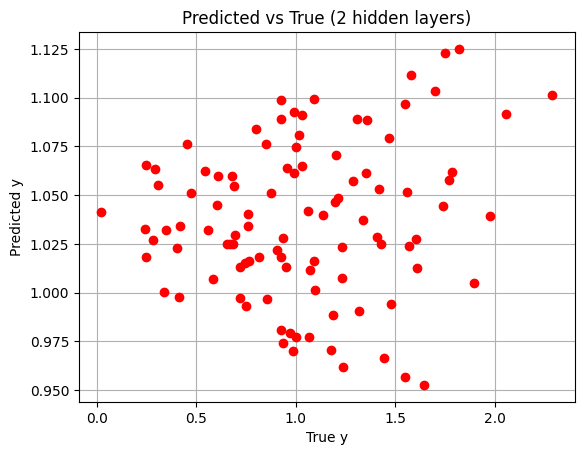

In [34]:
# ---- Evaluación ----
_, _, _, _, y_pred = forward(x)
plt.plot(y, y_pred, 'ro')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Predicted vs True (2 hidden layers)")
plt.grid()
plt.show()

In [35]:
tf.__version__

'2.19.0'